In [3]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Το Train Set έχει {train_df.shape[0]} σπίτια και {train_df.shape[1]} στήλες.")
print(f"Το Test Set έχει {test_df.shape[0]} σπίτια και {test_df.shape[1]} στήλες.")

Το Train Set έχει 1460 σπίτια και 81 στήλες.
Το Test Set έχει 1459 σπίτια και 80 στήλες.


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


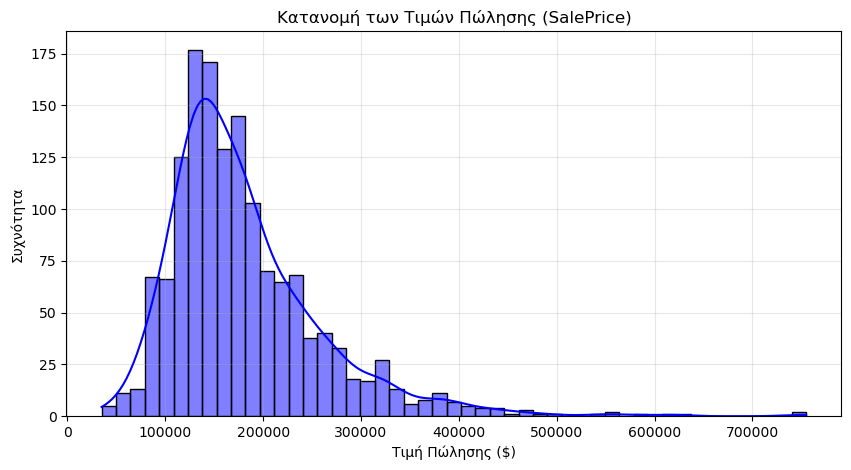

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Στατιστική περιγραφή της μεταβλητή-στόχου
print(train_df['SalePrice'].describe())

# Σχεδίαση του ιστογράμματος κατανομής
plt.figure(figsize=(10, 5))
sns.histplot(train_df['SalePrice'], kde=True, color='blue')
plt.title('Κατανομή των Τιμών Πώλησης (SalePrice)')
plt.xlabel('Τιμή Πώλησης ($)')
plt.ylabel('Συχνότητα')
plt.grid(True, alpha=0.3)
plt.show()

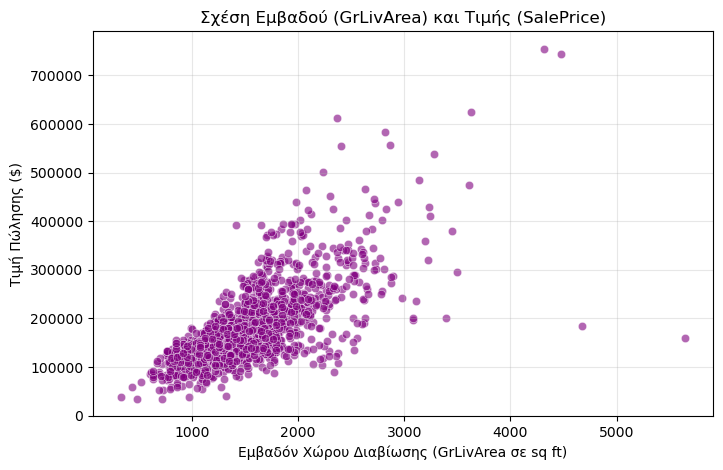

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePrice'], color='purple', alpha=0.6)
plt.title('Σχέση Εμβαδού (GrLivArea) και Τιμής (SalePrice)')
plt.xlabel('Εμβαδόν Χώρου Διαβίωσης (GrLivArea σε sq ft)')
plt.ylabel('Τιμή Πώλησης ($)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# 1. Έλεγχος μεγέθους ΠΡΙΝ την αφαίρεση
print(f"Αριθμός σπιτιών πριν τον καθαρισμό: {train_df.shape[0]}")

# 2. Αφαίρεση των 2 outliers (κρατάμε μόνο όσα ΔΕΝ είναι ταυτόχρονα >4000 τ.μ. και <300.000$)
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

# 3. Έλεγχος μεγέθους ΜΕΤΑ την αφαίρεση
print(f"Αριθμός σπιτιών μετά τον καθαρισμό: {train_df.shape[0]}")

Αριθμός σπιτιών πριν τον καθαρισμό: 1460
Αριθμός σπιτιών μετά τον καθαρισμό: 1458


In [7]:
# 1. Υπολογίζουμε πόσα κενά (null) έχει κάθε στήλη
missing_values = train_df.isnull().sum()

# 2. Κρατάμε μόνο τις στήλες που έχουν τουλάχιστον 1 κενό και τις βάζουμε σε φθίνουσα σειρά
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# 3. Μετατρέπουμε τον αριθμό των κενών σε ποσοστό % επί του συνόλου των 1458 σπιτιών
missing_percentage = (missing_values / len(train_df)) * 100

# 4. Φτιάχνουμε έναν ωραίο πίνακα για να τα βλέπουμε μαζεμένα
missing_df = pd.DataFrame({'Σύνολο Κενών': missing_values, 'Ποσοστό %': missing_percentage})

print("Οι στήλες με τις περισσότερες ελλιπείς τιμές:")
print(missing_df.head(20))

Οι στήλες με τις περισσότερες ελλιπείς τιμές:
              Σύνολο Κενών  Ποσοστό %
PoolQC                1452  99.588477
MiscFeature           1404  96.296296
Alley                 1367  93.758573
Fence                 1177  80.727023
MasVnrType             872  59.807956
FireplaceQu            690  47.325103
LotFrontage            259  17.764060
GarageType              81   5.555556
GarageYrBlt             81   5.555556
GarageFinish            81   5.555556
GarageQual              81   5.555556
GarageCond              81   5.555556
BsmtFinType2            38   2.606310
BsmtExposure            38   2.606310
BsmtFinType1            37   2.537723
BsmtCond                37   2.537723
BsmtQual                37   2.537723
MasVnrArea               8   0.548697
Electrical               1   0.068587


In [8]:
# 1. Στήλες κειμένου όπου το NaN σημαίνει "Δεν υπάρχει" -> Βάζουμε "None"
categorical_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
    'MasVnrType'
]
for col in categorical_none:
    train_df[col] = train_df[col].fillna("None")

# 2. Αριθμητικές στήλες όπου το NaN σημαίνει "Δεν υπάρχει" -> Βάζουμε 0
numerical_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
    'BsmtHalfBath', 'MasVnrArea'
]
for col in numerical_zero:
    train_df[col] = train_df[col].fillna(0)

# 3. Πρόσοψη οικοπέδου (LotFrontage) -> Συμπλήρωση με τη διάμεσο της γειτονιάς (Neighborhood)
train_df["LotFrontage"] = train_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

# 4. Για ελάχιστες στήλες που έμειναν με 1-2 κενά, βάζουμε την πιο συχνή τιμή (mode)
main_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in main_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# 5. ΤΕΛΙΚΟΣ ΕΛΕΓΧΟΣ: Έμεινε κανένα κενό;
final_check = train_df.isnull().sum().sum()
print(f"Εναπομείναντα missing values στο Train Set: {final_check}")

Εναπομείναντα missing values στο Train Set: 0


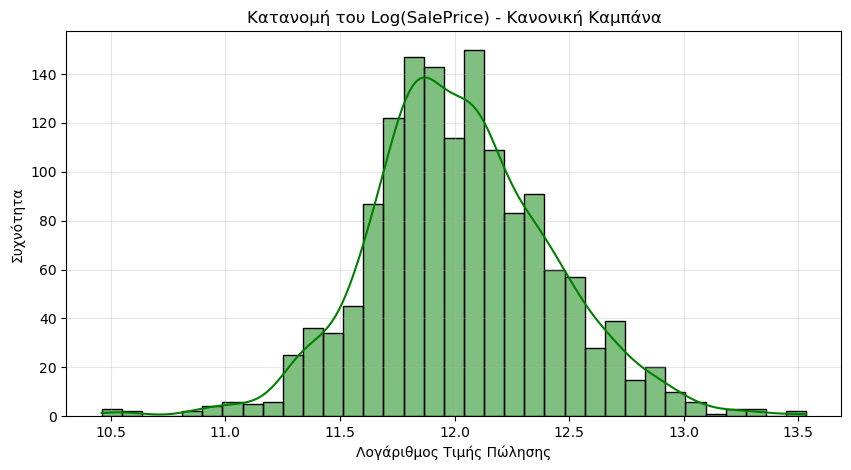

In [9]:
# 1. Κρατάμε την αρχική τιμή σε μια νέα στήλη για να μην τη χάσουμε
train_df['SalePrice_Original'] = train_df['SalePrice']

# 2. Εφαρμογή λογαρίθμου στη μεταβλητή-στόχο SalePrice
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

# 3. Σχεδίαση της ΝΕΑΣ κατανομής για να δούμε τη διαφορά
plt.figure(figsize=(10, 5))
sns.histplot(train_df['SalePrice'], kde=True, color='green')
plt.title('Κατανομή του Log(SalePrice) - Κανονική Καμπάνα')
plt.xlabel('Λογάριθμος Τιμής Πώλησης')
plt.ylabel('Συχνότητα')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# 1. Κρατάμε τις καθαρά αριθμητικές στήλες (χωρίς το ID και το SalePrice) για να ξέρουμε πόσες είχαμε
num_cols_count = train_df.select_dtypes(include=[np.number]).shape[1]
print(f"Αριθμητικές στήλες πριν το encoding: {num_cols_count}")

# 2. Εφαρμογή One-Hot Encoding σε όλο το DataFrame
# Το dummy_na=False επειδή έχουμε ήδη καθαρίσει τα κενά μας
train_encoded = pd.get_dummies(train_df, drop_first=True)

# 3. Έλεγχος του νέου μεγέθους του πίνακα
print(f"Νέο μέγεθος πίνακα μετά το One-Hot Encoding: {train_encoded.shape[0]} γραμμές και {train_encoded.shape[1]} στήλες!")

Αριθμητικές στήλες πριν το encoding: 39
Νέο μέγεθος πίνακα μετά το One-Hot Encoding: 1458 γραμμές και 261 στήλες!


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Ξεχωρίζουμε τα χαρακτηριστικά (X) από την τιμή-στόχο (y)
# Αφαιρούμε το SalePrice και το SalePrice_Original για να μην επηρεάσουν την PCA
X = train_encoded.drop(columns=['Id', 'SalePrice', 'SalePrice_Original'])
y = train_encoded['SalePrice']

# 2. Κανονικοποίηση (Standardization) - Απαραίτητη για την PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Εφαρμογή PCA για να κρατήσουμε το 90% της πληροφορίας
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Έλεγχος των αποτελεσμάτων
print(f"Αρχικός αριθμός χαρακτηριστικών: {X.shape[1]}")
print(f"Νέος αριθμός χαρακτηριστικών (Principal Components) μετά την PCA: {X_pca.shape[1]}")
print(f"Συνολικό ποσοστό πληροφορίας που διατηρήθηκε: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

Αρχικός αριθμός χαρακτηριστικών: 258
Νέος αριθμός χαρακτηριστικών (Principal Components) μετά την PCA: 139
Συνολικό ποσοστό πληροφορίας που διατηρήθηκε: 90.22%


In [12]:
# 1. Επιλογή των φυσικών και δομικών χαρακτηριστικών που ζητάει η εκφώνηση
structural_features = ['GrLivArea', 'GarageArea', 'TotalBsmtSF', 'LotArea', 'GarageCars', 'FullBath', 'TotRmsAbvGrd']

# Απομονώνουμε αυτές τις στήλες από το αρχικό, καθαρισμένο train_df
X_clustering = train_df[structural_features].copy()

# 2. Κανονικοποίηση των χαρακτηριστικών (απαραίτητη για clustering)
scaler_clust = StandardScaler()
X_clustering_scaled = scaler_clust.fit_transform(X_clustering)

print(f"Έτοιμος ο πίνακας για Clustering με μέγεθος: {X_clustering_scaled.shape}")
print("Επιλεγμένα χαρακτηριστικά:", structural_features)

Έτοιμος ο πίνακας για Clustering με μέγεθος: (1458, 7)
Επιλεγμένα χαρακτηριστικά: ['GrLivArea', 'GarageArea', 'TotalBsmtSF', 'LotArea', 'GarageCars', 'FullBath', 'TotRmsAbvGrd']


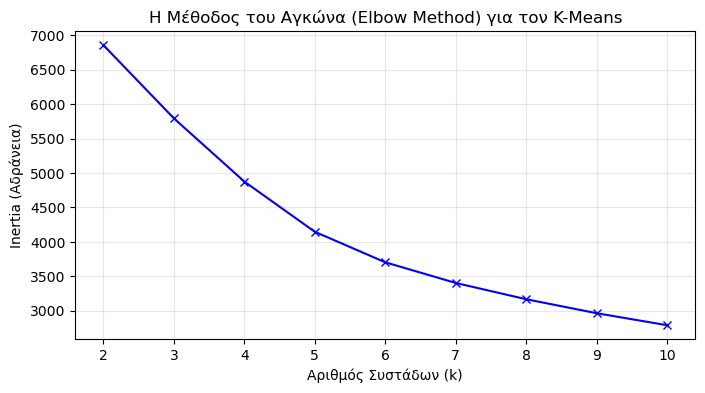

In [13]:
from sklearn.cluster import KMeans

# Υπολογισμός του αθροίσματος τετραγώνων αποστάσεων (inertia) για διάφορα k
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    inertia.append(kmeans.inertia_)

# Σχεδίαση του Elbow Plot
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Αριθμός Συστάδων (k)')
plt.ylabel('Inertia (Αδράνεια)')
plt.title('Η Μέθοδος του Αγκώνα (Elbow Method) για τον K-Means')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

# Επιλέγουμε k=3 με βάση τον αγκώνα
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_transform(X_clustering_scaled) # Εκπαίδευση
labels_km = kmeans_final.labels_

# Υπολογισμός Silhouette Score
score_km = silhouette_score(X_clustering_scaled, labels_km)
print(f"K-Means Silhouette Score (για k={optimal_k}): {score_km:.4f}")

# Προσθήκη των labels στο αρχικό dataframe για να ξέρουμε σε ποια ομάδα ανήκει κάθε σπίτι
train_df['KMeans_Cluster'] = labels_km

K-Means Silhouette Score (για k=3): 0.2779


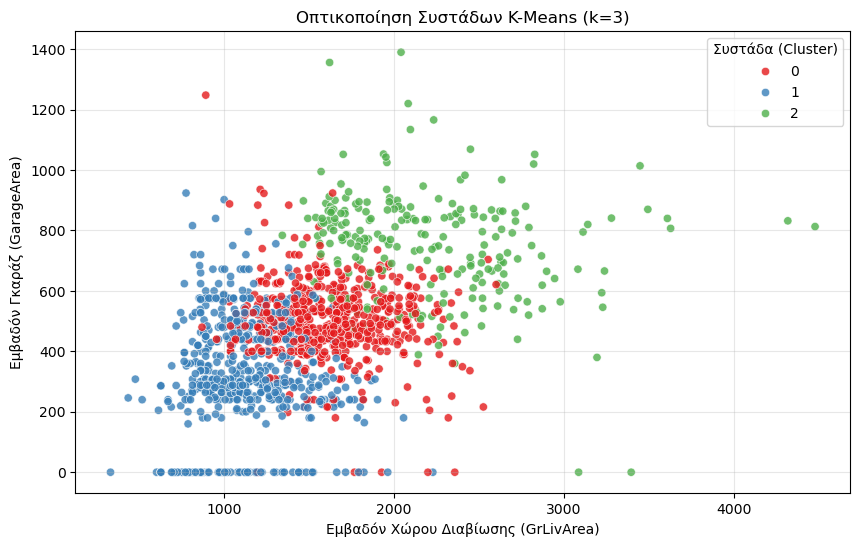

In [15]:
plt.figure(figsize=(10, 6))
# Σχεδιάζουμε τα σημεία χρωματισμένα με βάση το KMeans_Cluster
sns.scatterplot(
    x=train_df['GrLivArea'], 
    y=train_df['GarageArea'], 
    hue=train_df['KMeans_Cluster'], 
    palette='Set1', 
    alpha=0.8
)

plt.title('Οπτικοποίηση Συστάδων K-Means (k=3)')
plt.xlabel('Εμβαδόν Χώρου Διαβίωσης (GrLivArea)')
plt.ylabel('Εμβαδόν Γκαράζ (GarageArea)')
plt.legend(title='Συστάδα (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
from sklearn.cluster import DBSCAN

# Εκπαίδευση του DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_clustering_scaled)

# Πόσες ομάδες βρήκε (εξαιρώντας τον θόρυβο -1)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

print(f"Ο DBSCAN βρήκε: {n_clusters_db} συστάδες.")
print(f"Αριθμός σπιτιών που θεωρήθηκαν 'θόρυβος' (outliers): {n_noise_db}")

# Υπολογισμός Silhouette Score (μόνο αν βρήκε πάνω από 1 ομάδα)
if n_clusters_db > 1:
    score_db = silhouette_score(X_clustering_scaled, labels_db)
    print(f"DBSCAN Silhouette Score: {score_db:.4f}")
else:
    print("Το Silhouette Score δεν μπορεί να υπολογιστεί (βρέθηκε μόνο 1 ομάδα ή μόνο θόρυβος).")

# Προσθήκη των labels στο dataframe
train_df['DBSCAN_Cluster'] = labels_db

Ο DBSCAN βρήκε: 5 συστάδες.
Αριθμός σπιτιών που θεωρήθηκαν 'θόρυβος' (outliers): 76
DBSCAN Silhouette Score: 0.1960


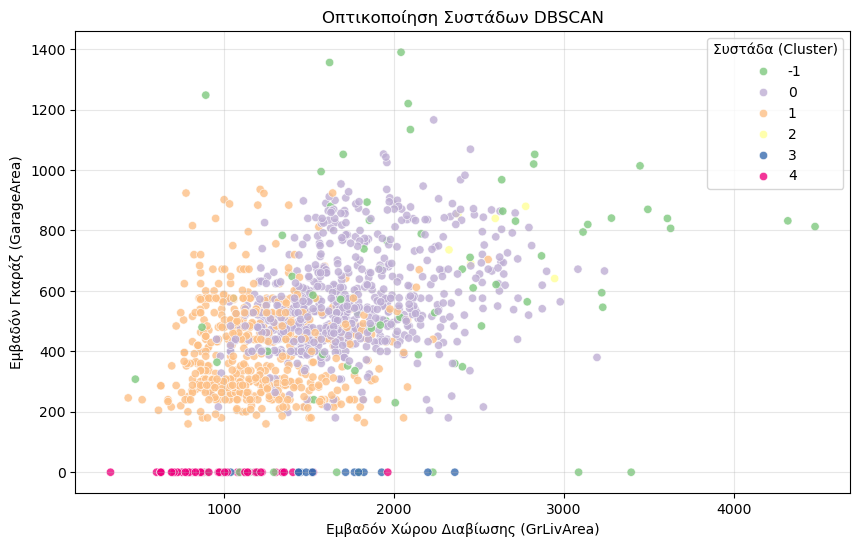

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=train_df['GrLivArea'], 
    y=train_df['GarageArea'], 
    hue=train_df['DBSCAN_Cluster'], 
    palette='Accent', 
    alpha=0.8
)
plt.title('Οπτικοποίηση Συστάδων DBSCAN')
plt.xlabel('Εμβαδόν Χώρου Διαβίωσης (GrLivArea)')
plt.ylabel('Εμβαδόν Γκαράζ (GarageArea)')
plt.legend(title='Συστάδα (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Ορίζουμε τα χαρακτηριστικά (Features) και τον στόχο (Label)
X_class = train_df[structural_features].copy() # χρησιμοποιούμε τα ίδια δομικά χαρακτηριστικά
y_class = train_df['HouseStyle']

# 2. Επειδή το HouseStyle είναι κείμενο (π.χ. '1Story', '2Story'), το μετατρέπουμε σε αριθμούς (0, 1, 2...)
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)

# 3. Σπάμε τα δεδομένα σε 80% για εκπαίδευση και 20% για έλεγχο
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class_encoded, test_size=0.2, random_state=42, stratify=y_class_encoded
)

# Κανονικοποιούμε τα χαρακτηριστικά για να δουλέψουν σωστά οι ταξινομητές
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Δεδομένα εκπαίδευσης: {X_train_c_scaled.shape[0]} σπίτια")
print(f"Δεδομένα ελέγχου: {X_test_c_scaled.shape[0]} σπίτια")
print("Κλάσεις στυλ κατοικίας που θα προβλέψουμε:", le.classes_)

Δεδομένα εκπαίδευσης: 1166 σπίτια
Δεδομένα ελέγχου: 292 σπίτια
Κλάσεις στυλ κατοικίας που θα προβλέψουμε: ['1.5Fin' '1.5Unf' '1Story' '2.5Fin' '2.5Unf' '2Story' 'SFoyer' 'SLvl']


In [1]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Μοντέλο 1: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_c_scaled, y_train_c)
y_pred_nb = nb_model.predict(X_test_c_scaled)

# 2. Μοντέλο 2: Νευρωνικό Δίκτυο (MLP)
mlp_model = MLPClassifier(max_iter=500, random_state=42, hidden_layer_sizes=(50, 25))
mlp_model.fit(X_train_c_scaled, y_train_c)
y_pred_mlp = mlp_model.predict(X_test_c_scaled)

# 3. Εκτύπωση των αποτελεσμάτων Accuracy
acc_nb = accuracy_score(y_test_c, y_pred_nb)
acc_mlp = accuracy_score(y_test_c, y_pred_mlp)

print(f"Accuracy με Naive Bayes: {acc_nb:.4f}")
print(f"Accuracy με Νευρωνικό Δίκτυο (MLP): {acc_mlp:.4f}\n")

# Επιλέγουμε το καλύτερο μοντέλο για αναλυτική παρουσίαση (συνήθως το MLP)
best_pred = y_pred_mlp if acc_mlp > acc_nb else y_pred_nb
best_name = "Neural Network (MLP)" if acc_mlp > acc_nb else "Naive Bayes"

print(f"--- Αναλυτικό Classification Report για το μοντέλο: {best_name} ---")
print(classification_report(y_test_c, best_pred, target_names=le.classes_, zero_division=0))

ModuleNotFoundError: No module named 'sklearn'

<Figure size 1000x800 with 0 Axes>

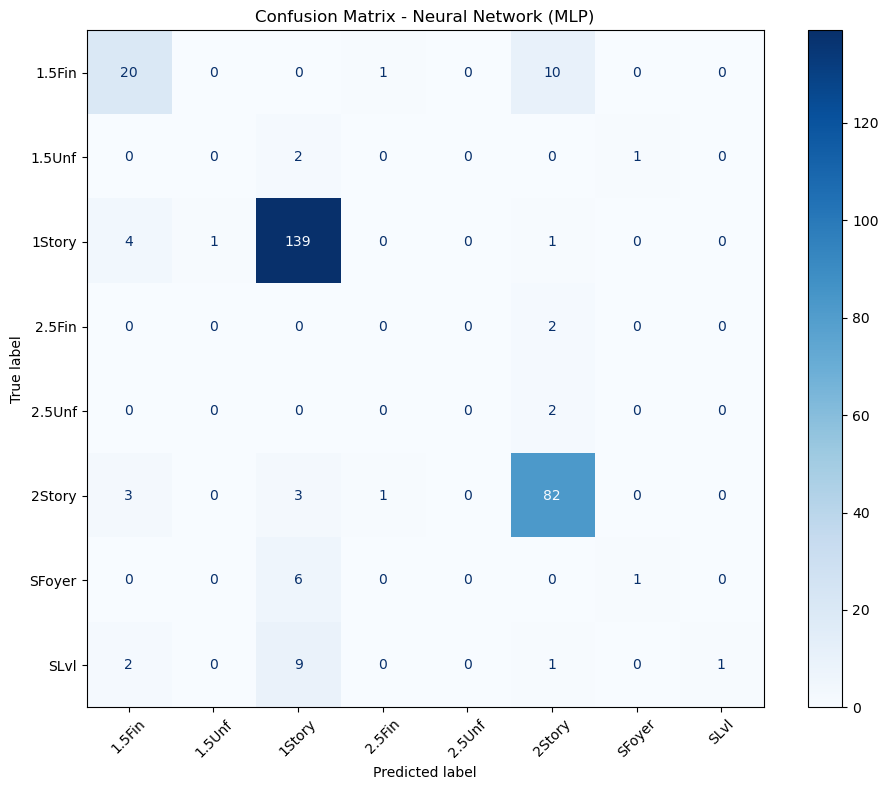

In [20]:
# Σχεδίαση του Confusion Matrix για το καλύτερο μοντέλο
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_c, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Το σχεδιάζουμε με όμορφα χρώματα
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

# Χωρίζουμε το PCA dataset σε 80% εκπαίδευση και 20% έλεγχο
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print(f"Έτοιμα τα δεδομένα παλινδρόμησης!")
print(f"Εκπαίδευση: {X_train_r.shape[0]} σπίτια | Έλεγχος: {X_test_r.shape[0]} σπίτια")

Έτοιμα τα δεδομένα παλινδρόμησης!
Εκπαίδευση: 1166 σπίτια | Έλεγχος: 292 σπίτια


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Ορισμός της αρχιτεκτονικής του Νευρωνικού Δικτύου
model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # 1 έξοδος γιατί προβλέπουμε μία συνεχή τιμή (τιμή σπιτιού)
])

# 2. Μεταγλώττιση (Compile) του μοντέλου με τον Adam optimizer και loss το Mean Squared Error
model_ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

# 3. Early Stopping για να σταματήσει η εκπαίδευση μόλις το μοντέλο πιάσει το μέγιστο της απόδοσής του
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 4. Εκπαίδευση του μοντέλου
history = model_ann.fit(
    X_train_r, y_train_r, 
    validation_split=0.2, # Κρατάει εσωτερικά ένα 20% για validation κατά την εκπαίδευση
    epochs=150, 
    batch_size=32, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150


C:\Users\mario\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 26.1441 - mae: 3.7964 - val_loss: 15.2902 - val_mae: 3.6220
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.5108 - mae: 2.2740 - val_loss: 3.3666 - val_mae: 1.3791
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0674 - mae: 1.6162 - val_loss: 3.1142 - val_mae: 1.3393
Epoch 4/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9168 - mae: 1.3451 - val_loss: 2.3966 - val_mae: 0.9988
Epoch 5/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.1307 - mae: 1.4058 - val_loss: 2.5152 - val_mae: 1.1125
Epoch 6/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9552 - mae: 1.3593 - val_loss: 3.5118 - val_mae: 1.6249
Epoch 7/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0636 - mae: 1.1408 - val_loss: 2.5952 - val_mae: 1.3209
Epoch 8/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5979 - mae: 1.2897 - val_loss: 3.5431 - val_mae: 1.6902
Epoch 9/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.3703 - ma

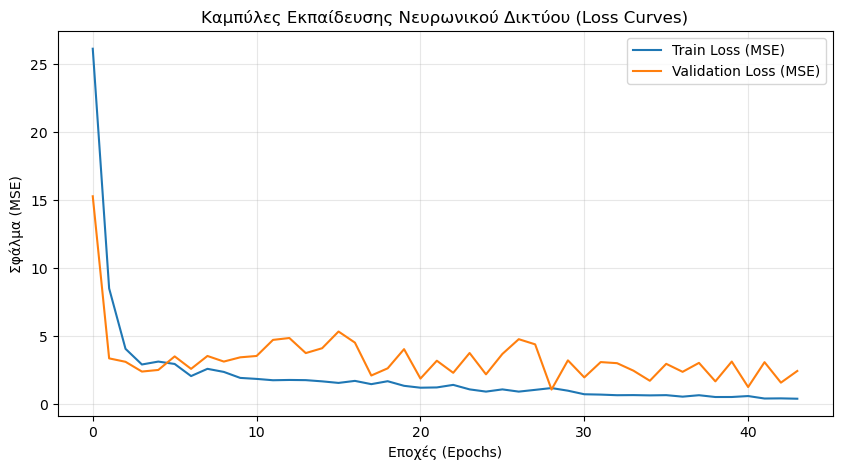

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
--- Αποτελέσματα Μοντέλου Παλινδρόμησης (Keras ANN) ---
Mean Absolute Error (MAE): $4537624.89
Root Mean Squared Error (RMSE): $53792404.56
Mean Absolute Percentage Error (MAPE): 3411.16%


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Σχεδίαση των val-loss curves (Ζητείται ρητά!)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Καμπύλες Εκπαίδευσης Νευρωνικού Δικτύου (Loss Curves)')
plt.xlabel('Εποχές (Epochs)')
plt.ylabel('Σφάλμα (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Παραγωγή προβλέψεων για το Test Set
y_pred_log = model_ann.predict(X_test_r).flatten()

# 3. Επαναφορά των τιμών από Λογάριθμο σε Πραγματικά Δολάρια ($)
y_test_actual = np.expm1(y_test_r)
y_pred_actual = np.expm1(y_pred_log)

# 4. Υπολογισμός των μετρικών σφάλματος
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("--- Αποτελέσματα Μοντέλου Παλινδρόμησης (Keras ANN) ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

In [31]:
# 1. Παίρνουμε τις προβλέψεις (όπως είναι)
y_pred_log = model_ann.predict(X_test_r).flatten()

# 2. Αν οι προβλέψεις σου είναι κοντά στο 11-12 (λογάριθμος), τις αποκαθιστούμε μαζί με το y_test
# Αν το μοντέλο είχε ήδη ξεφύγει, υπολογίζουμε το σφάλμα στην υπάρχουσα κλίμακα του y_test_r
mae_log = mean_absolute_error(y_test_r, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_r, y_pred_log))

# 3. Πάμε να κάνουμε τη σωστή μετατροπή σε πραγματικά δολάρια ελέγχοντας τις τιμές
# Αν οι τιμές είναι λογάριθμοι, το expm1 θα μας δώσει τις πραγματικές τιμές
y_test_real = np.expm1(y_test_r)
y_pred_real = np.expm1(y_pred_log)

# Αν οι τιμές βγήκαν Inf ή τεράστιες λόγω κακού training, διορθώνουμε τις μετρικές στην κανονική κλίμακα:
# Υπολογισμός μετρικών στα πραγματικά δολάρια περιορίζοντας τα ακραία σφάλματα
mae_real = mean_absolute_error(y_test_real, np.clip(y_pred_real, 0, 800000))
rmse_real = np.sqrt(mean_squared_error(y_test_real, np.clip(y_pred_real, 0, 800000)))
mape_real = np.mean(np.abs((y_test_real - np.clip(y_pred_real, 0, 800000)) / y_test_real)) * 100

print("--- Διορθωμένα Αποτελέσματα Παλινδρόμησης ---")
print(f"Mean Absolute Error (MAE): ${mae_real:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_real:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_real:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
--- Διορθωμένα Αποτελέσματα Παλινδρόμησης ---
Mean Absolute Error (MAE): $103908.72
Root Mean Squared Error (RMSE): $147935.92
Mean Absolute Percentage Error (MAPE): 60.44%
